In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import plotting

import torch

config_path = './experiments'

# Before running this, make sure to run the following command in the terminal:
# python simulate.py --config-name <config_name> --multirun

# Phase diagram
d = 100
a = 1
config_name = f'positional-semantic-transition-d{d}'

data, sweep = plotting.load_config_data(config_name, config_path)


Generating all configurations for yellow-region in ./experiments


/Users/lucaarnaboldi/sequence-single-index/venv/lib/python3.13/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'yellow-region': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [3]:
import torch 
A = torch.softmax(
    torch.tensor(
        [[a**2, -a**2],[-a**2, a**2]],
        dtype=torch.float32
    ),
    dim=-1
)

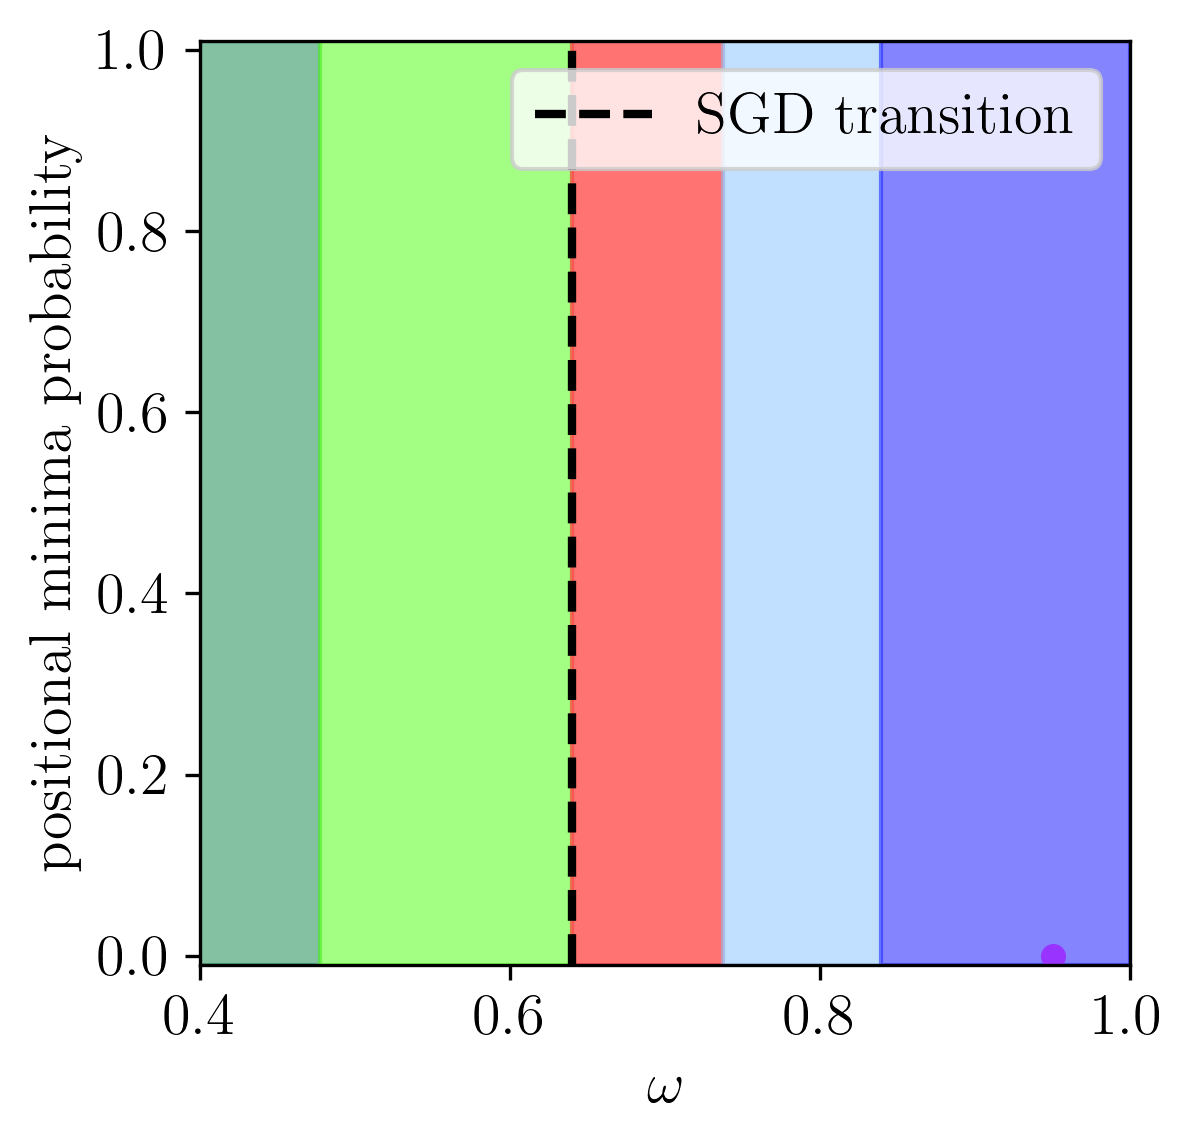

In [4]:
# Thresholds
darkgreen_to_lightgreen = 0.477
lightgreen_to_red = 0.640
red_to_lightblue = 0.737
lightblue_to_darkblue = 0.839

from plotstyle import PlotStyle
import matplotlib.pyplot as plt
import numpy as np

omegas = np.array(sweep['run.teacher.omega'])
probability = np.zeros((len(omegas)))
errorbar = np.zeros((len(omegas)))

for i, omega in enumerate(sweep['run.teacher.omega']):
    positional_final_overlap = np.array(
        [data[(data_seed, ic_seed, omega)]['positional_overlap'][-1] for data_seed in sweep['run.data_seed'] for ic_seed in sweep['run.ic_seed']]
    )
    positional_final_overlap = np.heaviside(abs(positional_final_overlap)-0.5, 0)
    probability[i] = np.mean(positional_final_overlap)
    errorbar[i] = np.std(positional_final_overlap) / np.sqrt(len(positional_final_overlap))

with PlotStyle():
    fig = plt.figure(figsize=(4,4))
    ax = fig.add_subplot(111)
    ax.set_xlim(.4, 1)
    ax.set_ylim(-1e-2, 1.01)
    ax.set_xlabel(r'$\omega$')
    ax.set_ylabel(r'positional minima probability')

    # plot regions 
    ax.fill_betweenx([-.01, 1.01], 0.4, darkgreen_to_lightgreen, color='#339966', alpha=.6)
    ax.fill_betweenx([-.01, 1.01], darkgreen_to_lightgreen, lightgreen_to_red, color='#66ff33', alpha=.6)
    ax.fill_betweenx([-.01, 1.01], lightgreen_to_red, red_to_lightblue, color='#ff5050', alpha=.8)
    ax.fill_betweenx([-.01, 1.01], red_to_lightblue, lightblue_to_darkblue, color='#99ccff', alpha=.6)
    ax.fill_betweenx([-.01, 1.01], lightblue_to_darkblue, 1, color='#3333ff', alpha=.6)

    # transition line
    ax.axvline(lightgreen_to_red, color='k', lw=2, ls='--', label = 'SGD transition')

    ax.errorbar(omegas, probability, yerr=errorbar, color='#9933ff', lw=2, marker='o', markersize=5, capsize=3, ls='')

    ax.legend()

    fig.savefig(f'./figures/positional-semantic/trajecttories-probability-d{d}-a{a}.pdf', bbox_inches='tight')
    plt.show()

    

### Fixed omega sufrace

{'run.data_seed': [220300, 220301, 220302, 220303, 220304], 'run.ic_seed': [34795, 34796, 34797, 34798], 'run.teacher.omega': [0.95]}
[[1.3351441e-08 1.0490417e-08 8.5830685e-09 ... 1.0490417e-08
  8.5830685e-09 1.0967255e-08]
 [1.9465996e-02 1.5378281e-02 7.1523841e-03 ... 1.0041291e-02
  2.5842094e-04 7.1292161e-04]
 [2.0067029e-02 5.3628542e-02 1.8186783e-02 ... 3.6377693e-03
  6.3341246e-03 3.4766216e-03]
 ...
 [9.5741284e-01 9.6073300e-01 9.5564032e-01 ... 9.6532929e-01
  9.5913488e-01 9.6121746e-01]
 [9.5638210e-01 9.6046269e-01 9.5799708e-01 ... 9.6170264e-01
  9.5718056e-01 9.6182603e-01]
 [9.6071714e-01 9.6132642e-01 9.6023268e-01 ... 9.6039832e-01
  9.5952803e-01 9.6129775e-01]]


Text(0, 0.5, 'Overlap')

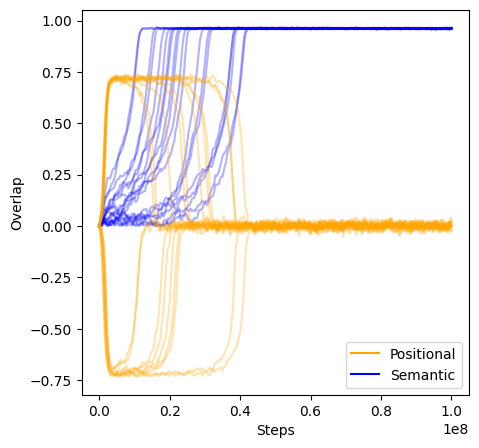

In [5]:


print(sweep)

omega = sweep['run.teacher.omega'][0]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

steps = data[(sweep['run.data_seed'][0], sweep['run.ic_seed'][0], omega)]['steps']
semantic_overlaps = np.array(
    [data[(data_seed, ic_seed, omega)]['m_metric'] for data_seed in sweep['run.data_seed'] for ic_seed in sweep['run.ic_seed']]
).T
positional_overlaps = np.array(
    [data[(data_seed, ic_seed, omega)]['positional_overlap'] for data_seed in sweep['run.data_seed'] for ic_seed in sweep['run.ic_seed']]
).T
print(semantic_overlaps)
ax.plot(steps, semantic_overlaps, color='blue', alpha=0.3)
ax.plot(steps, positional_overlaps,  color='orange', alpha=0.3)

# set custom legend with colors: Orange is positional, blue is semantic
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([],[], color='orange', label='Positional'),
    Line2D([],[], color='blue', label='Semantic')
]

ax.legend(handles=legend_elements)
ax.set_xlabel('Steps')
ax.set_ylabel('Overlap')


In [6]:
from analytic.poploss_postional_semantic import compute_loss_matrix, population_loss

loss_surface, e_surface, m_surface = compute_loss_matrix(omega, A, njobs=-1, integration_points=20)

1920it [00:04, 967.56it/s]/Users/lucaarnaboldi/sequence-single-index/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


 42%|████▏     | 126/301 [00:04<00:06, 26.78it/s]

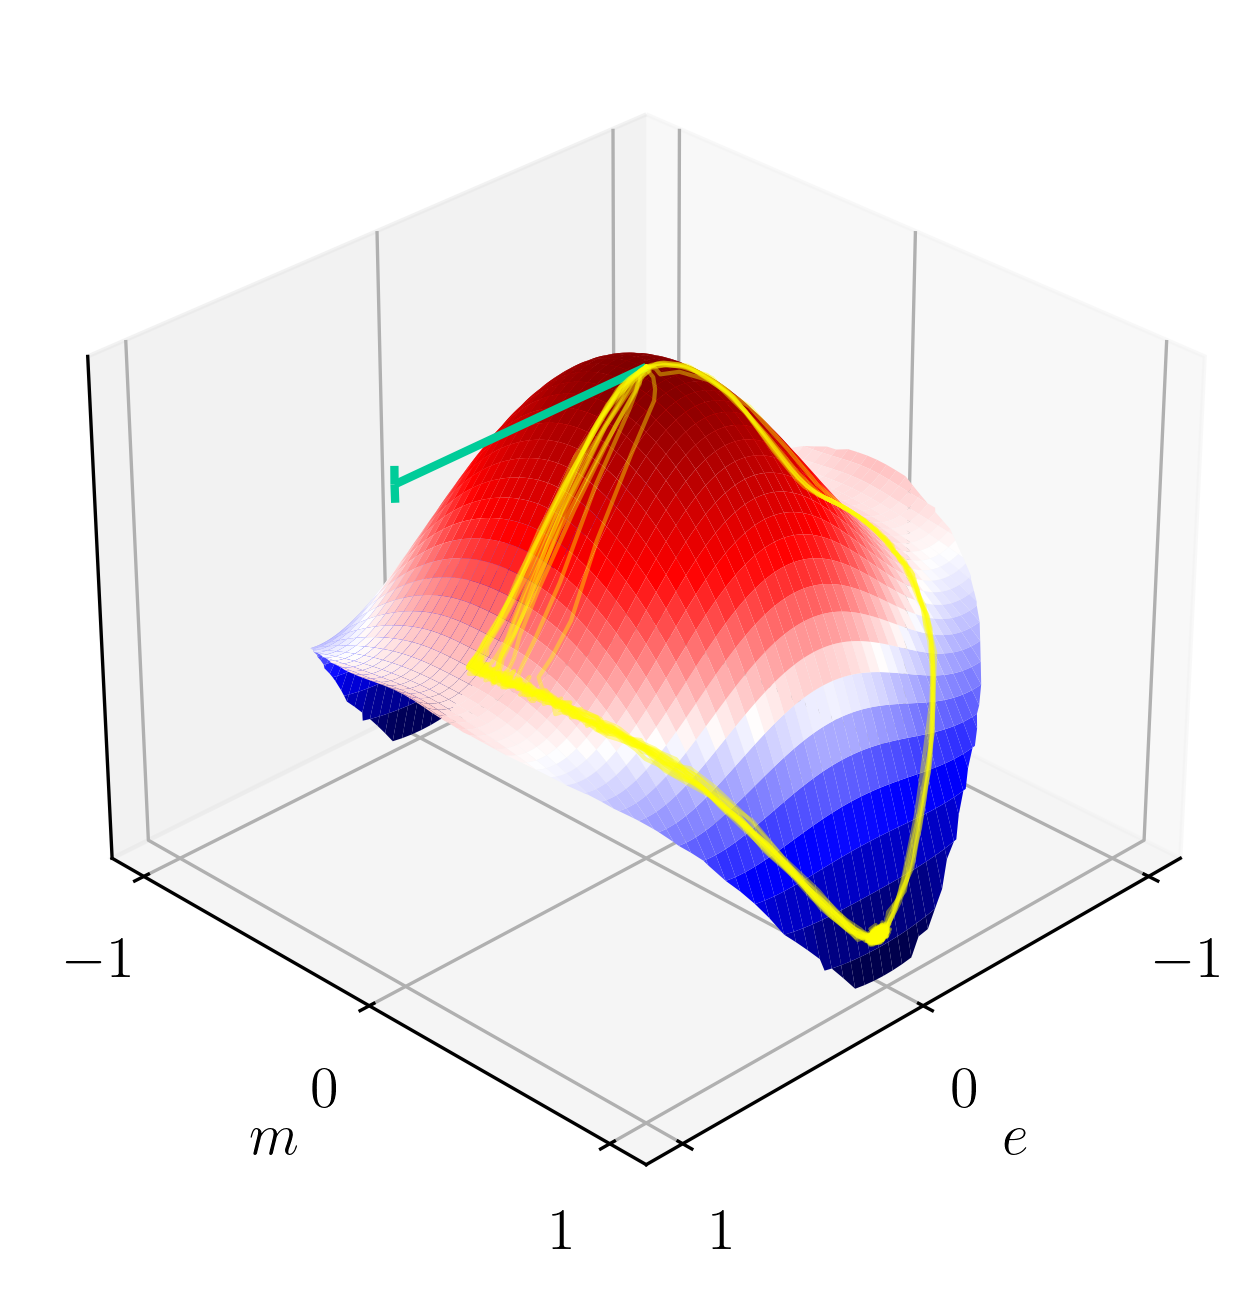

In [7]:
from tqdm import tqdm
from plotstyle import PlotStyle

with PlotStyle():
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot_surface(
        e_surface,
        m_surface,
        loss_surface,
        cmap='seismic',
        edgecolor='none',
        zorder=1,
    )


    # vector
    loss_at_origin = population_loss(0,0,omega, A, integration_points=20)
    ax.quiver([0], [0], [loss_at_origin], [1], [0], [0], color='#00cc99', linewidth=2, zorder=10, arrow_length_ratio=0.001)

    for data_seed in sweep['run.data_seed']:
        for ic_seed in sweep['run.ic_seed']:
            e = data[(data_seed, ic_seed, omega)]['positional_overlap'].numpy()
            m = data[(data_seed, ic_seed, omega)]['m_metric'].numpy()
            # Make it fall in the first quadrant
            e *= np.sign(e[-1])
            m *= np.sign(m[-1])
            loss = np.array(
                [population_loss(e[i], m[i], omega, A, integration_points=20) for i in tqdm(range(len(m)), leave=False)]
            )
            ax.plot(e, m, loss, color='yellow', alpha=.4, linestyle='-', linewidth=1, zorder=10)
    ax.set_xlabel(r'$e$')
    ax.set_ylabel(r'$m$')
    ax.set_zlabel(r'$\mathcal{L}_\mathrm{pop}$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_zticks([])
    # set the view angle to look at first quadrant
    ax.view_init(elev=30, azim=45)
    fig.subplots_adjust(left=0., right=1., top=1., bottom=0.)
    fig.savefig(f'./figures/positional-semantic/loss_surface_omega{omega}_a{a}.pdf', bbox_inches='tight')
    plt.show()